# AML-Shield — 01: Exploratory Data Analysis

**Dataset:** IBM Transactions for Anti-Money Laundering (AML)  
**Source:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml  
**File used:** `HI-Small_Trans.csv` (High Illicit ratio, ~5M transactions)  
**Author:** AML-Shield Project  

---

## Objectives
1. Understand dataset structure and schema
2. Assess data quality (missing values, dtypes, anomalies)
3. Analyse class imbalance — the core challenge in fraud detection
4. Uncover transaction patterns that distinguish laundering from legitimate activity
5. Document findings to inform feature engineering strategy

---
**Column Reference (IBM AML Dataset):**
```
Timestamp         — Transaction datetime
From Bank         — Sending bank ID
From Account      — Sending account ID  
To Bank           — Receiving bank ID
To Account        — Receiving account ID
Amount Received   — Amount received by destination
Receiving Currency— Currency of received amount
Amount Paid       — Amount sent by source
Payment Currency  — Currency of paid amount
Payment Format    — Transaction type (Cheque, Credit Card, etc.)
Is Laundering     — Target label: 1 = money laundering, 0 = legitimate
```

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Plotting defaults ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
PALETTE = {'legit': '#2196F3', 'fraud': '#F44336'}

# ── Paths ──────────────────────────────────────────────────────────
DATA_DIR  = Path('../data')
FIG_DIR   = Path('../src/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE  = DATA_DIR / 'HI-Small_Trans.csv'

print('✅ Imports loaded')
print(f'📁 Data path : {RAW_FILE.resolve()}')
print(f'📁 Figures   : {FIG_DIR.resolve()}')

✅ Imports loaded
📁 Data path : /Users/fripuran/aml-shield-main/data/HI-Small_Trans.csv
📁 Figures   : /Users/fripuran/aml-shield-main/src/figures


## 1. Load Dataset

The IBM AML dataset has **two columns both named `Account`** (one for sender, one for receiver).  
Pandas automatically suffixes the duplicate as `Account.1`.  
We rename both immediately for clarity.

In [2]:
# ── Load raw CSV ───────────────────────────────────────────────────
df = pd.read_csv(RAW_FILE, low_memory=False)

# ── Fix duplicate 'Account' column names ──────────────────────────
# Pandas reads them as 'Account' and 'Account.1'
df = df.rename(columns={
    'Account'  : 'From Account',
    'Account.1': 'To Account'
})

# ── Parse timestamp ────────────────────────────────────────────────
# Format in file: 'DD-MM-YY H:MM' e.g. '01-09-22 0:20'
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='mixed', dayfirst=True)

print('=== DATASET LOADED SUCCESSFULLY ===')
print(f'Rows       : {df.shape[0]:>12,}')
print(f'Columns    : {df.shape[1]:>12}')
print(f'Date range : {df["Timestamp"].min()} → {df["Timestamp"].max()}')
print(f'Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
df.head(5)

=== DATASET LOADED SUCCESSFULLY ===
Rows       :    5,078,345
Columns    :           11
Date range : 2022-01-09 00:00:00 → 2022-12-09 23:51:00
Memory     : 652.3 MB



,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-01-09 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022-01-09 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022-01-09 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022-01-09 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022-01-09 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


## 2. Schema & Data Types

In [3]:
# ── Data types ─────────────────────────────────────────────────────
print('=== COLUMN DATA TYPES ===')
type_summary = pd.DataFrame({
    'dtype'        : df.dtypes,
    'null_count'   : df.isnull().sum(),
    'null_pct'     : (df.isnull().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique(),
    'sample_value' : df.iloc[0]
})
print(type_summary.to_string())

=== COLUMN DATA TYPES ===
                             dtype  null_count  null_pct  unique_values         sample_value
Timestamp           datetime64[us]           0       0.0          15018  2022-01-09 00:20:00
From Bank                    int64           0       0.0          30470                   10
From Account                   str           0       0.0         496995            8000EBD30
To Bank                      int64           0       0.0          15811                   10
To Account                     str           0       0.0         420636            8000EBD30
Amount Received            float64           0       0.0         915161              3697.34
Receiving Currency             str           0       0.0             15            US Dollar
Amount Paid                float64           0       0.0         923873              3697.34
Payment Currency               str           0       0.0             15            US Dollar
Payment Format                 str          

In [4]:
# ── Descriptive statistics for numeric columns ─────────────────────
print('=== DESCRIPTIVE STATISTICS ===')
df.describe(include='all').T

=== DESCRIPTIVE STATISTICS ===


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Timestamp,5078345,NaN,NaN,NaN,2022-05-05 19:48:47.161616,2022-01-09 00:00:00,2022-02-09 04:32:00,2022-05-09 12:16:00,2022-08-09 03:13:00,2022-12-09 23:51:00,NaN
From Bank,5078345.0,NaN,NaN,NaN,45730.565729,1.0,119.0,9679.0,28628.0,356303.0,81765.622281
From Account,5078345,496995,100428660,168672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
To Bank,5078345.0,NaN,NaN,NaN,65744.562853,1.0,4259.0,21568.0,122332.0,356294.0,84092.990137
To Account,5078345,420636,100428660,1084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount Received,5078345.0,NaN,NaN,NaN,5988726.070073,0.000001,183.37,1411.01,12346.27,1046302363293.47998,1037183108.891989
Receiving Currency,5078345,15,US Dollar,1879341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount Paid,5078345.0,NaN,NaN,NaN,4509273.367741,0.000001,184.48,1414.54,12297.84,1046302363293.47998,869772830.919865
Payment Currency,5078345,15,US Dollar,1895172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment Format,5078345,7,Cheque,1864331,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Class Imbalance Analysis

This is the **most important section** of EDA for fraud detection.  
Class imbalance means the model can achieve high accuracy by always predicting 'legitimate' —  
so accuracy is a meaningless metric here. We use **AUC-ROC** and **Precision-Recall** instead.

=== CLASS DISTRIBUTION ===
Legitimate (0) :  5,073,168  (99.90%)
Laundering (1) :      5,177  (0.10%)
Imbalance ratio: 979.9:1  (legitimate:fraud)

⚠️  IMPLICATION: A naive model predicting everything as legit
   achieves 99.9% accuracy but catches ZERO fraud.
   → We must use scale_pos_weight + evaluate with AUC-ROC / F1.


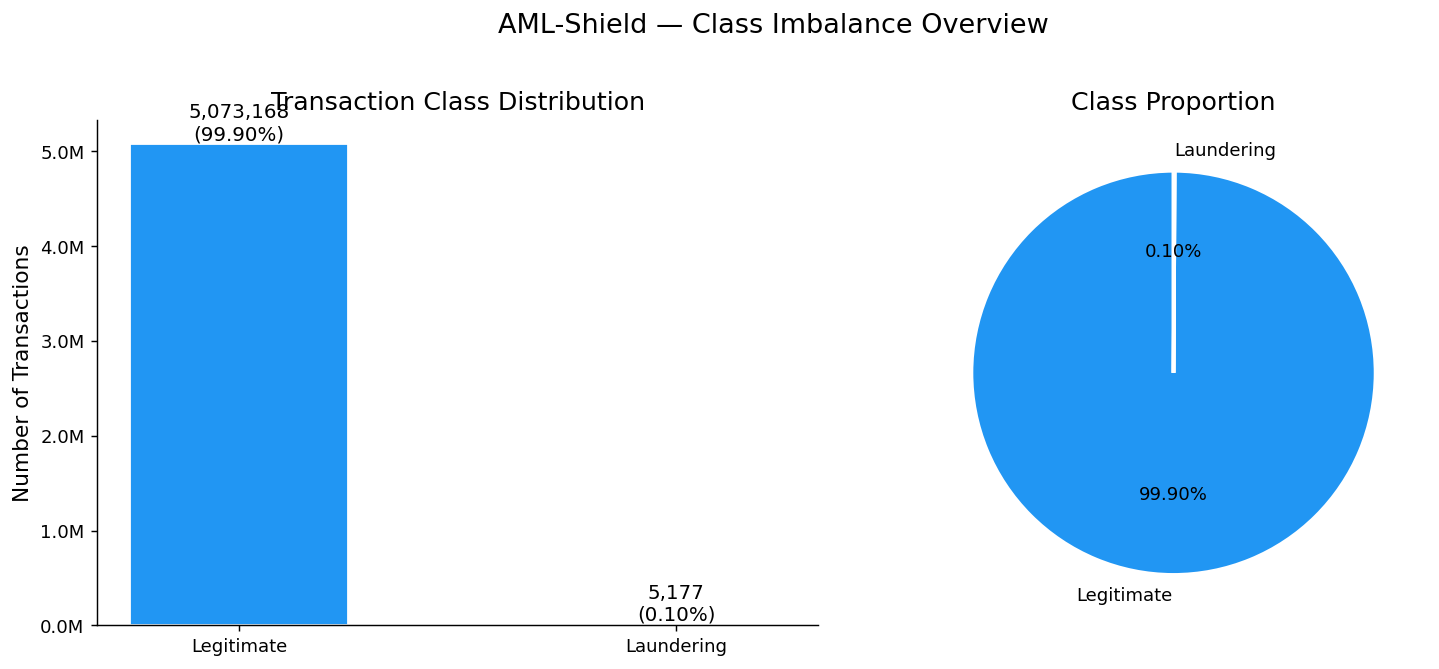

📊 Chart saved.


In [5]:
# ── Class distribution ─────────────────────────────────────────────
counts     = df['Is Laundering'].value_counts()
pcts       = df['Is Laundering'].value_counts(normalize=True) * 100
fraud_rate = df['Is Laundering'].mean() * 100

print('=== CLASS DISTRIBUTION ===')
print(f"Legitimate (0) : {counts[0]:>10,}  ({pcts[0]:.2f}%)")
print(f"Laundering (1) : {counts[1]:>10,}  ({pcts[1]:.2f}%)")
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1  (legitimate:fraud)")
print()
print('⚠️  IMPLICATION: A naive model predicting everything as legit')
print(f'   achieves {pcts[0]:.1f}% accuracy but catches ZERO fraud.')
print('   → We must use scale_pos_weight + evaluate with AUC-ROC / F1.')

# ── Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(
    ['Legitimate', 'Laundering'], counts.values,
    color=[PALETTE['legit'], PALETTE['fraud']], edgecolor='white', width=0.5
)
for bar, count, pct in zip(bars, counts.values, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{count:,}\n({pct:.2f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Transaction Class Distribution')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Pie chart
axes[1].pie(
    counts.values,
    labels=['Legitimate', 'Laundering'],
    colors=[PALETTE['legit'], PALETTE['fraud']],
    autopct='%1.2f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Proportion')

plt.suptitle('AML-Shield — Class Imbalance Overview', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved.')

## 4. Transaction Amount Analysis

=== AMOUNT PAID STATISTICS BY CLASS ===
                count         mean           std  min      25%      50%       75%           max
Legitimate  5073168.0   4477000.04  8.688463e+08  0.0   184.16  1410.99  12279.34  1.046302e+12
Laundering     5177.0  36135310.41  1.527919e+09  0.0  2634.97  8667.21  18832.27  8.485314e+10


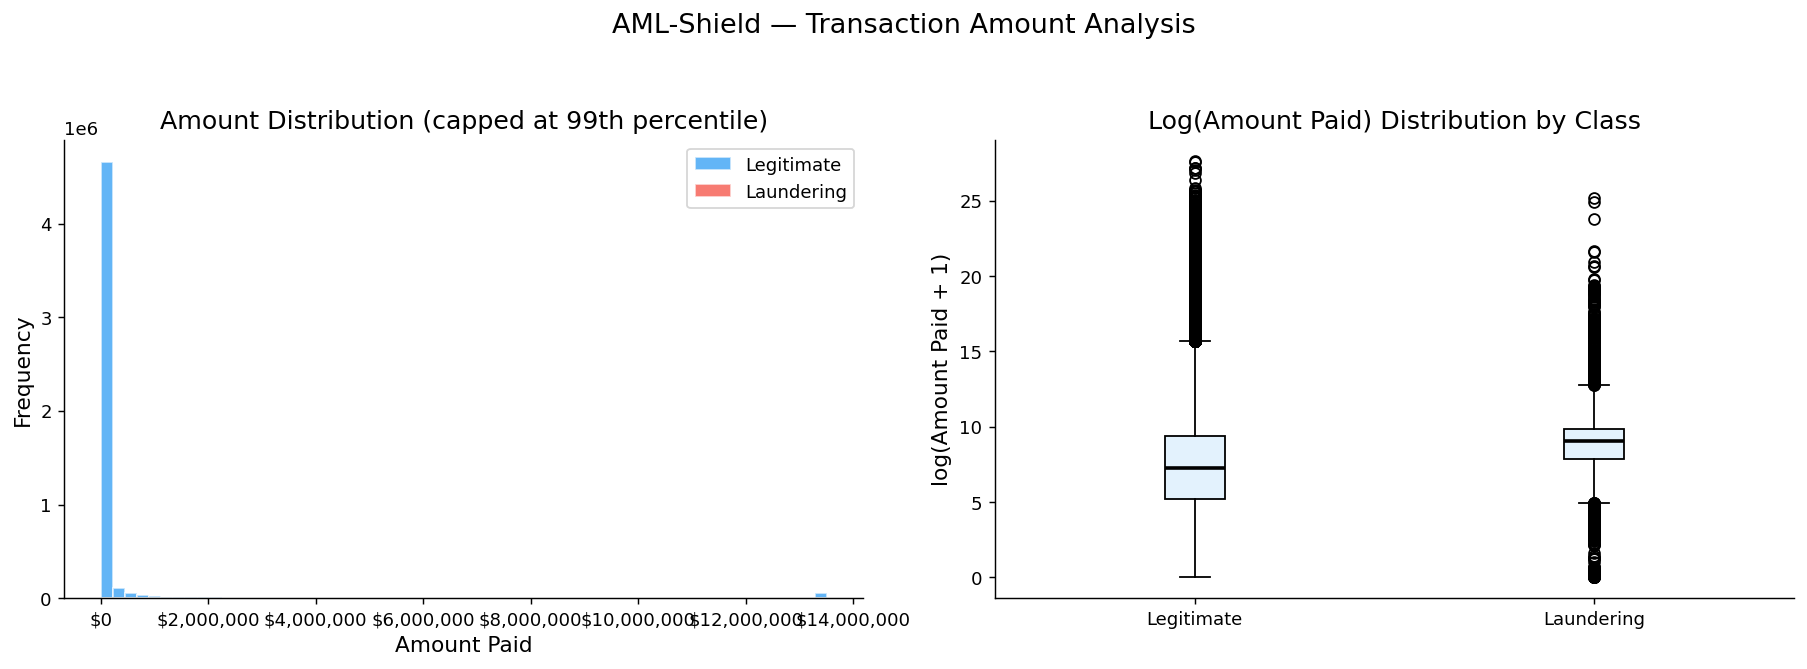

📊 Chart saved.


In [6]:
# ── Summary stats by class ─────────────────────────────────────────
amount_stats = df.groupby('Is Laundering')['Amount Paid'].describe().round(2)
amount_stats.index = ['Legitimate', 'Laundering']
print('=== AMOUNT PAID STATISTICS BY CLASS ===')
print(amount_stats.to_string())

legit = df[df['Is Laundering'] == 0]['Amount Paid']
fraud = df[df['Is Laundering'] == 1]['Amount Paid']
cap   = legit.quantile(0.99)   # cap at 99th percentile for readability

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution (capped)
axes[0].hist(legit.clip(upper=cap), bins=60, color=PALETTE['legit'],
             alpha=0.7, edgecolor='white', label='Legitimate')
axes[0].hist(fraud.clip(upper=cap), bins=60, color=PALETTE['fraud'],
             alpha=0.7, edgecolor='white', label='Laundering')
axes[0].set_title('Amount Distribution (capped at 99th percentile)')
axes[0].set_xlabel('Amount Paid')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log-scale box plot
plot_df = df[['Amount Paid', 'Is Laundering']].copy()
plot_df['Class'] = plot_df['Is Laundering'].map({0: 'Legitimate', 1: 'Laundering'})
plot_df['log_amount'] = np.log1p(plot_df['Amount Paid'])

axes[1].boxplot(
    [np.log1p(legit), np.log1p(fraud)],
    labels=['Legitimate', 'Laundering'],
    patch_artist=True,
    boxprops=dict(facecolor='#e3f2fd'),
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_title('Log(Amount Paid) Distribution by Class')
axes[1].set_ylabel('log(Amount Paid + 1)')

plt.suptitle('AML-Shield — Transaction Amount Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved.')

## 5. Payment Format Analysis

=== FRAUD RATE BY PAYMENT FORMAT ===
Payment Format  total_transactions  fraud_count  fraud_rate_pct
           ACH              600797         4483            0.75
       Bitcoin              146091           56            0.04
          Cash              490891          108            0.02
        Cheque             1864331          324            0.02
   Credit Card             1323324          206            0.02
  Reinvestment              481056            0            0.00
          Wire              171855            0            0.00

🔴 Most suspicious format: 'ACH' (0.75% fraud rate)


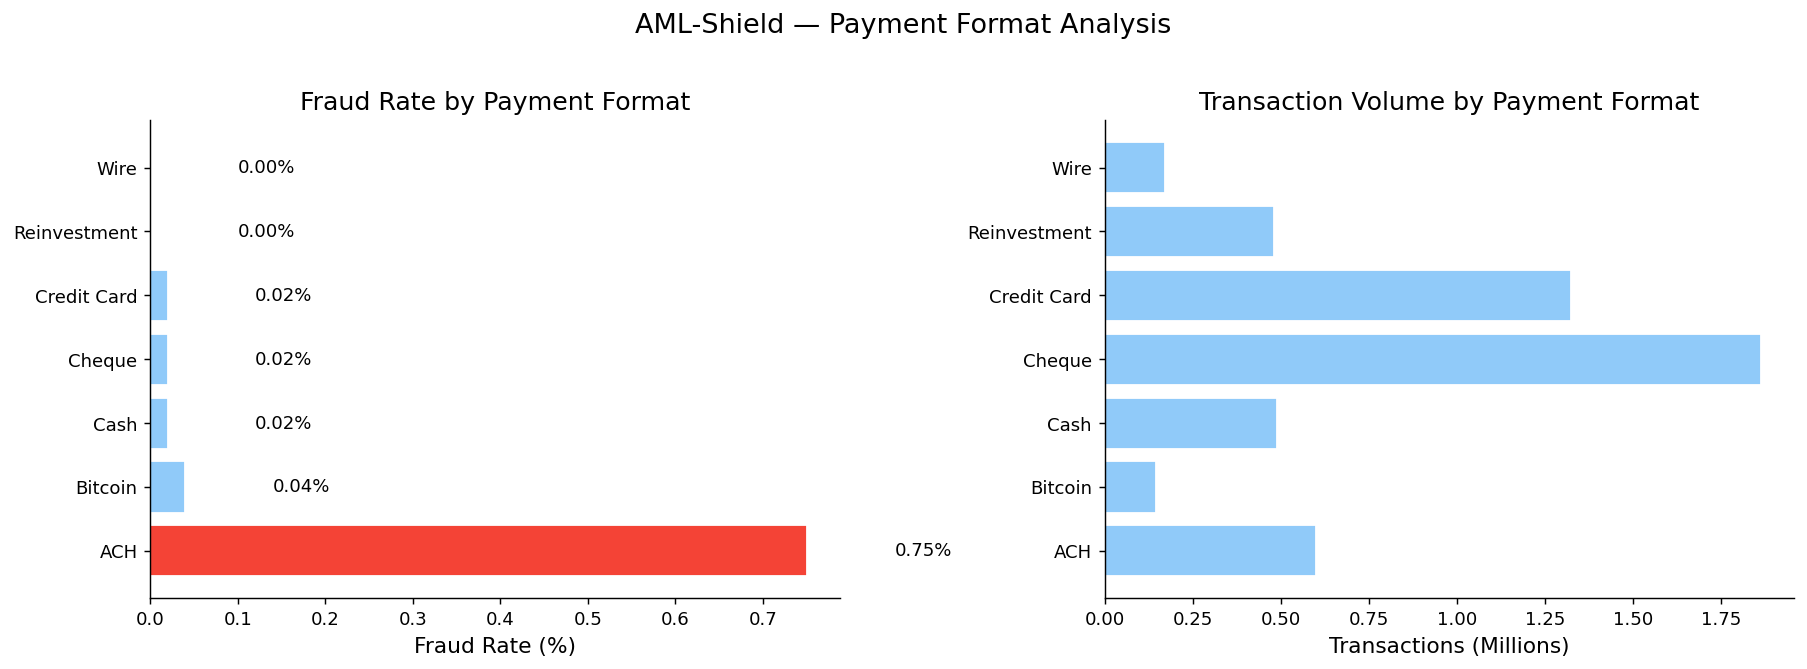

📊 Chart saved.


In [7]:
# ── Fraud rate by payment format ───────────────────────────────────
format_stats = (
    df.groupby('Payment Format')
    .agg(
        total_transactions=('Is Laundering', 'count'),
        fraud_count       =('Is Laundering', 'sum'),
        fraud_rate        =('Is Laundering', 'mean')
    )
    .assign(fraud_rate_pct=lambda x: (x['fraud_rate'] * 100).round(2))
    .sort_values('fraud_rate', ascending=False)
    .reset_index()
)

print('=== FRAUD RATE BY PAYMENT FORMAT ===')
print(format_stats[['Payment Format', 'total_transactions',
                     'fraud_count', 'fraud_rate_pct']].to_string(index=False))
print(f"\n🔴 Most suspicious format: '{format_stats.iloc[0]['Payment Format']}' "
      f"({format_stats.iloc[0]['fraud_rate_pct']:.2f}% fraud rate)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate bar
colors = [PALETTE['fraud'] if i == 0 else '#90CAF9'
          for i in range(len(format_stats))]
bars = axes[0].barh(format_stats['Payment Format'],
                    format_stats['fraud_rate_pct'],
                    color=colors, edgecolor='white')
for bar, val in zip(bars, format_stats['fraud_rate_pct']):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=10)
axes[0].set_title('Fraud Rate by Payment Format')
axes[0].set_xlabel('Fraud Rate (%)')

# Volume bar
axes[1].barh(format_stats['Payment Format'],
             format_stats['total_transactions'] / 1e6,
             color='#90CAF9', edgecolor='white')
axes[1].set_title('Transaction Volume by Payment Format')
axes[1].set_xlabel('Transactions (Millions)')

plt.suptitle('AML-Shield — Payment Format Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_payment_format_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved.')

## 6. Currency Analysis

=== FRAUD RATE: SAME vs CROSS-CURRENCY TRANSACTIONS ===
Same currency    : 0.10%
Cross currency   : 0.00%

=== TOP CURRENCIES BY FRAUD RATE (min 1,000 transactions) ===
Receiving Currency   total  fraud_rate_pct
       Saudi Riyal   89971            0.42
              Euro 1172017            0.12
         US Dollar 1879341            0.10
               Yen  156319            0.10
 Australian Dollar  138511            0.09
   Canadian Dollar  141357            0.09
              Yuan  206551            0.09
             Rupee  192065            0.09
             Ruble  157361            0.08
      Mexican Peso  111030            0.08


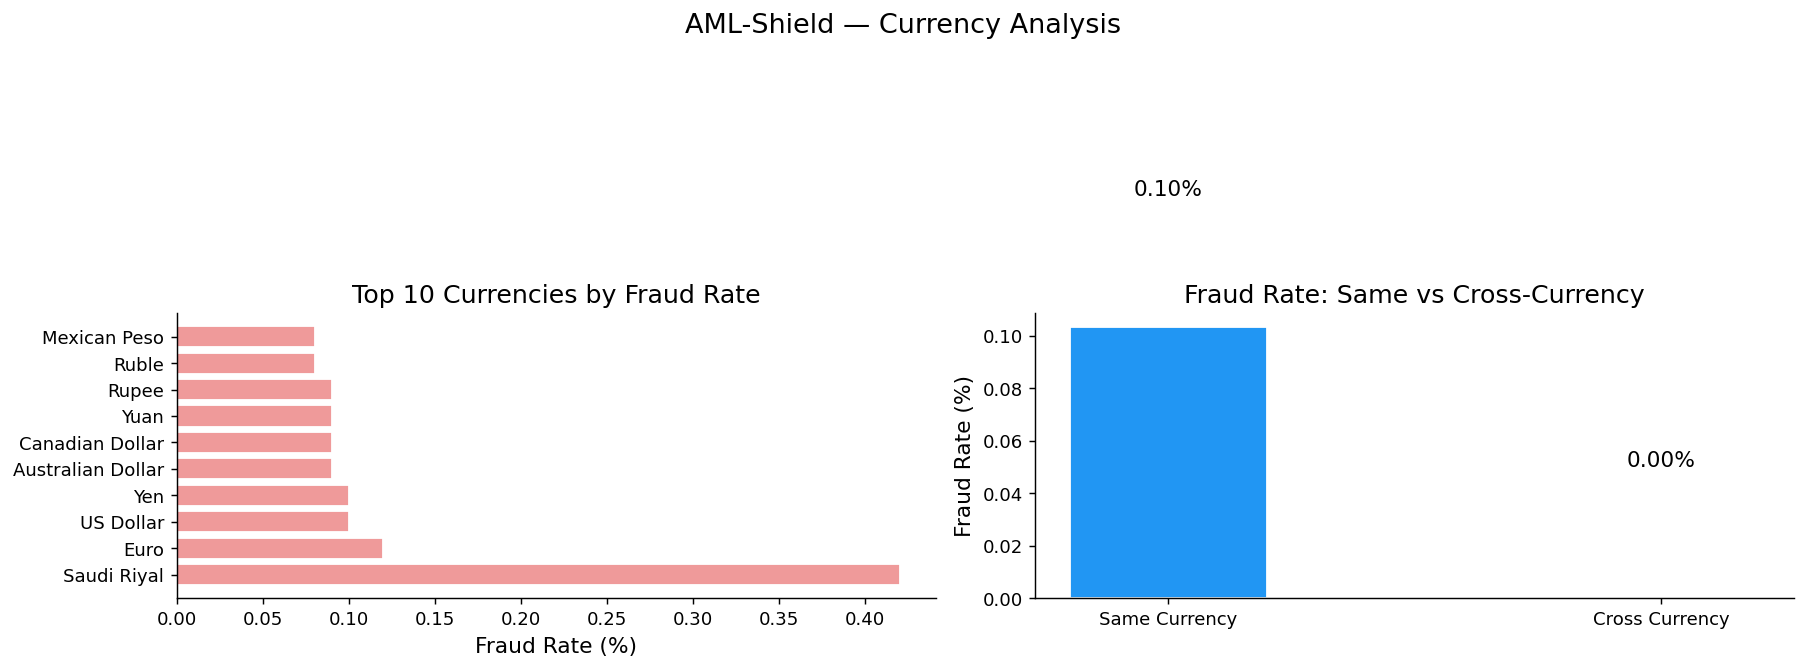

📊 Chart saved.


In [8]:
# ── Cross-currency transactions ────────────────────────────────────
# Laundering often involves currency conversion to obscure money trail
df['is_cross_currency'] = (
    df['Payment Currency'] != df['Receiving Currency']
).astype(int)

cross_currency_fraud = df.groupby('is_cross_currency')['Is Laundering'].mean() * 100
print('=== FRAUD RATE: SAME vs CROSS-CURRENCY TRANSACTIONS ===')
print(f"Same currency    : {cross_currency_fraud.get(0, 0):.2f}%")
print(f"Cross currency   : {cross_currency_fraud.get(1, 0):.2f}%")
print()

# ── Top currencies by fraud rate (min 1000 txns) ──────────────────
currency_stats = (
    df.groupby('Receiving Currency')
    .agg(
        total=('Is Laundering', 'count'),
        fraud_rate=('Is Laundering', 'mean')
    )
    .query('total > 1000')
    .assign(fraud_rate_pct=lambda x: (x['fraud_rate'] * 100).round(2))
    .sort_values('fraud_rate', ascending=False)
    .reset_index()
)

print('=== TOP CURRENCIES BY FRAUD RATE (min 1,000 transactions) ===')
print(currency_stats[['Receiving Currency', 'total', 'fraud_rate_pct']]
      .head(10).to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_curr = currency_stats.head(10)
axes[0].barh(top_curr['Receiving Currency'], top_curr['fraud_rate_pct'],
             color='#EF9A9A', edgecolor='white')
axes[0].set_title('Top 10 Currencies by Fraud Rate')
axes[0].set_xlabel('Fraud Rate (%)')

cross_labels = ['Same Currency', 'Cross Currency']
cross_values = [cross_currency_fraud.get(0, 0), cross_currency_fraud.get(1, 0)]
bars = axes[1].bar(cross_labels, cross_values,
                   color=[PALETTE['legit'], PALETTE['fraud']],
                   edgecolor='white', width=0.4)
for bar, val in zip(bars, cross_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontsize=12)
axes[1].set_title('Fraud Rate: Same vs Cross-Currency')
axes[1].set_ylabel('Fraud Rate (%)')

plt.suptitle('AML-Shield — Currency Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_currency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved.')

## 7. Temporal Analysis

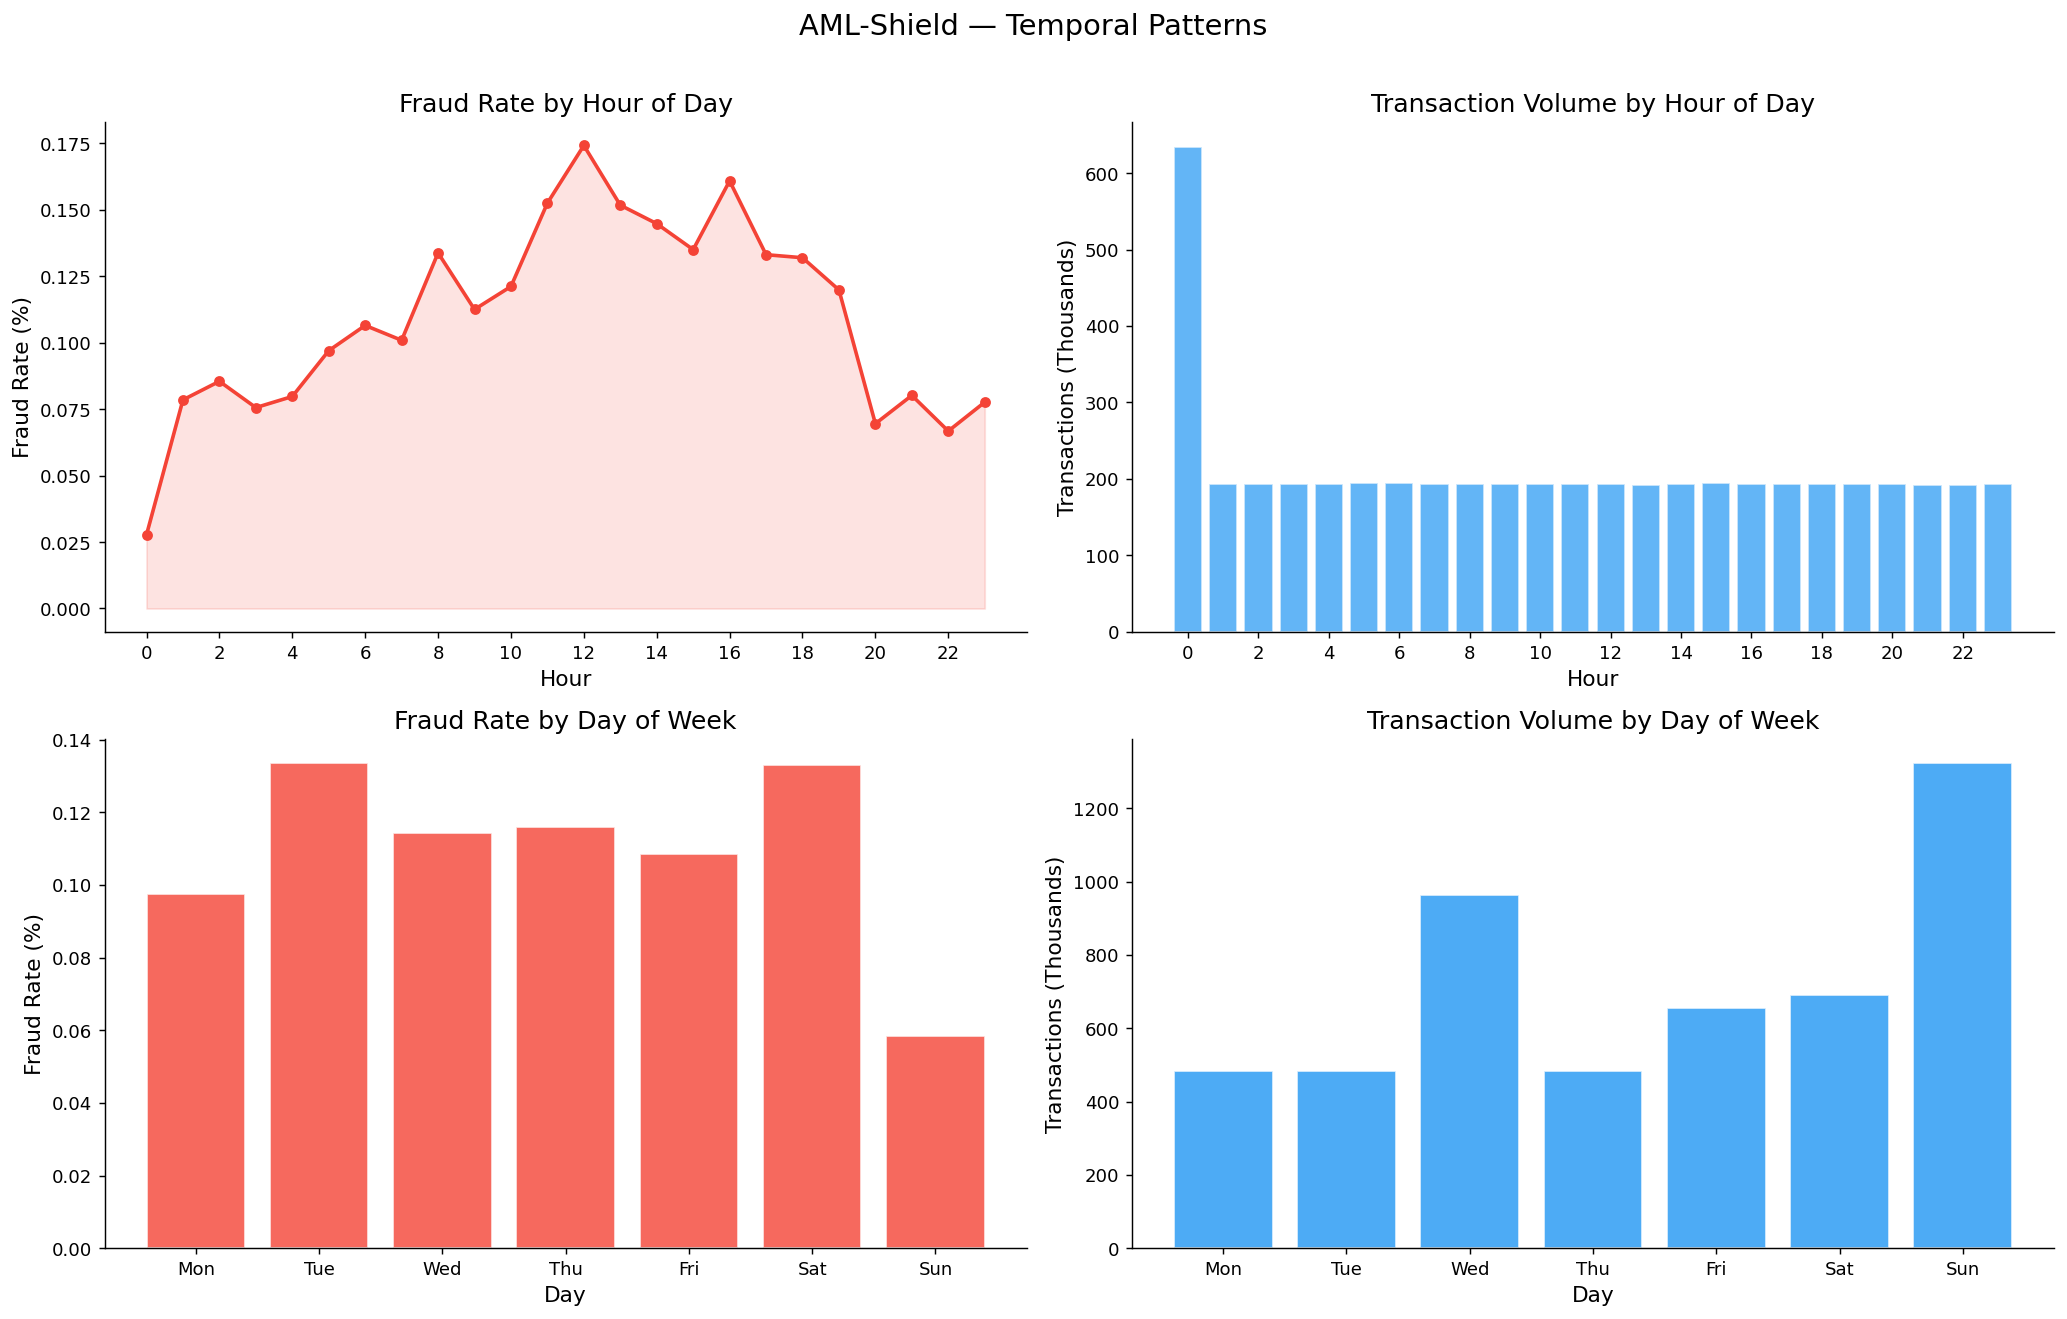

📊 Chart saved.


In [9]:
# ── Extract time components ────────────────────────────────────────
df['hour']        = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek  # 0=Mon, 6=Sun
df['day']         = df['Timestamp'].dt.day

# ── Fraud rate by hour ─────────────────────────────────────────────
hourly_fraud = (
    df.groupby('hour')['Is Laundering']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
    .reset_index()
)

# ── Fraud rate by day of week ──────────────────────────────────────
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_fraud = (
    df.groupby('day_of_week')['Is Laundering']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly fraud rate
axes[0, 0].plot(hourly_fraud['hour'], hourly_fraud['fraud_rate'] * 100,
                color=PALETTE['fraud'], marker='o', linewidth=2, markersize=5)
axes[0, 0].fill_between(hourly_fraud['hour'], hourly_fraud['fraud_rate'] * 100,
                         alpha=0.15, color=PALETTE['fraud'])
axes[0, 0].set_title('Fraud Rate by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Fraud Rate (%)')
axes[0, 0].set_xticks(range(0, 24, 2))

# Hourly transaction volume
axes[0, 1].bar(hourly_fraud['hour'], hourly_fraud['volume'] / 1000,
               color=PALETTE['legit'], alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Transaction Volume by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Transactions (Thousands)')
axes[0, 1].set_xticks(range(0, 24, 2))

# Day of week fraud rate
axes[1, 0].bar(dow_labels, dow_fraud['fraud_rate'] * 100,
               color=PALETTE['fraud'], alpha=0.8, edgecolor='white')
axes[1, 0].set_title('Fraud Rate by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Fraud Rate (%)')

# Day of week volume
axes[1, 1].bar(dow_labels, dow_fraud['volume'] / 1000,
               color=PALETTE['legit'], alpha=0.8, edgecolor='white')
axes[1, 1].set_title('Transaction Volume by Day of Week')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Transactions (Thousands)')

plt.suptitle('AML-Shield — Temporal Patterns', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved.')

## 8. Bank Network Analysis

In [10]:
# ── Is it the same bank sending to itself? ─────────────────────────
df['is_same_bank'] = (df['From Bank'] == df['To Bank']).astype(int)

same_bank_fraud = df.groupby('is_same_bank')['Is Laundering'].mean() * 100
print('=== FRAUD RATE: SAME BANK vs INTER-BANK TRANSFERS ===')
print(f"Same bank transfer  : {same_bank_fraud.get(1, 0):.2f}%")
print(f"Inter-bank transfer : {same_bank_fraud.get(0, 0):.2f}%")
print()

# ── Top sending banks by fraud involvement ─────────────────────────
bank_stats = (
    df.groupby('From Bank')
    .agg(
        total_sent  =('Is Laundering', 'count'),
        fraud_count =('Is Laundering', 'sum'),
        fraud_rate  =('Is Laundering', 'mean')
    )
    .query('total_sent > 500')
    .assign(fraud_rate_pct=lambda x: (x['fraud_rate'] * 100).round(2))
    .sort_values('fraud_rate', ascending=False)
    .reset_index()
)

print('=== TOP 10 SENDING BANKS BY FRAUD RATE (min 500 txns) ===')
print(bank_stats[['From Bank', 'total_sent', 'fraud_count', 'fraud_rate_pct']]
      .head(10).to_string(index=False))

=== FRAUD RATE: SAME BANK vs INTER-BANK TRANSFERS ===
Same bank transfer  : 0.01%
Inter-bank transfer : 0.12%

=== TOP 10 SENDING BANKS BY FRAUD RATE (min 500 txns) ===
 From Bank  total_sent  fraud_count  fraud_rate_pct
    231212         544           15            2.76
    148350        1362           31            2.28
    214749         756           16            2.12
     26302         505            9            1.78
     23289         908           16            1.76
    213952        2165           33            1.52
     11128        1166           14            1.20
    249176        1454           15            1.03
     19329        2779           25            0.90
     15231        3780           33            0.87


## 9. Round Number Analysis

A known money laundering technique called **'structuring'** involves breaking large sums into smaller round amounts to avoid detection thresholds.

In [11]:
# ── Round amount analysis ──────────────────────────────────────────
df['is_round_1000']  = (df['Amount Paid'] % 1000 == 0).astype(int)
df['is_round_10000'] = (df['Amount Paid'] % 10000 == 0).astype(int)
df['is_round_100']   = (df['Amount Paid'] % 100 == 0).astype(int)

for col, label in [
    ('is_round_100',   'Round $100'),
    ('is_round_1000',  'Round $1,000'),
    ('is_round_10000', 'Round $10,000'),
]:
    rate = df.groupby(col)['Is Laundering'].mean() * 100
    print(f"{label:20s} | Not round: {rate.get(0,0):.2f}%  | "
          f"Round: {rate.get(1,0):.2f}%")

print()
print('💡 INSIGHT: Round amounts may be a signal — launderers')
print('   often transact in exact figures to simplify bookkeeping.')

Round $100           | Not round: 0.10%  | Round: 0.16%
Round $1,000         | Not round: 0.10%  | Round: 0.00%
Round $10,000        | Not round: 0.10%  | Round: 0.00%

💡 INSIGHT: Round amounts may be a signal — launderers
   often transact in exact figures to simplify bookkeeping.


## 10. EDA Summary & Feature Engineering Implications

In [12]:
fraud_rate     = df['Is Laundering'].mean() * 100
imbalance_ratio = (df['Is Laundering'] == 0).sum() / (df['Is Laundering'] == 1).sum()
top_format     = format_stats.iloc[0]['Payment Format']
top_format_pct = format_stats.iloc[0]['fraud_rate_pct']
cross_pct      = cross_currency_fraud.get(1, 0)
same_pct       = cross_currency_fraud.get(0, 0)

print('=' * 60)
print('AML-SHIELD — EDA FINDINGS SUMMARY')
print('=' * 60)
print(f"Dataset size       : {len(df):,} transactions")
print(f"Fraud rate         : {fraud_rate:.2f}%")
print(f"Imbalance ratio    : {imbalance_ratio:.0f}:1 (legit:fraud)")
print()
print('KEY SIGNALS FOR FEATURE ENGINEERING:')
print(f"  1. Payment format — '{top_format}' has {top_format_pct}% fraud rate")
print(f"  2. Cross-currency — {cross_pct:.2f}% vs {same_pct:.2f}% (same currency)")
print(f"  3. Hour of day    — temporal patterns visible (see chart)")
print(f"  4. Round amounts  — structuring signal")
print(f"  5. Bank identity  — some banks disproportionately involved")
print(f"  6. Same-bank flag — transfer type matters")
print()
print('MODELLING DECISIONS:')
print(f"  • Do NOT use raw accuracy as metric")
print(f"  • Use AUC-ROC + Average Precision + F1")
print(f"  • Set XGBoost scale_pos_weight = {imbalance_ratio:.0f}")
print(f"  • Monitor False Negative rate (missed fraud) closely")
print('=' * 60)

AML-SHIELD — EDA FINDINGS SUMMARY
Dataset size       : 5,078,345 transactions
Fraud rate         : 0.10%
Imbalance ratio    : 980:1 (legit:fraud)

KEY SIGNALS FOR FEATURE ENGINEERING:
  1. Payment format — 'ACH' has 0.75% fraud rate
  2. Cross-currency — 0.00% vs 0.10% (same currency)
  3. Hour of day    — temporal patterns visible (see chart)
  4. Round amounts  — structuring signal
  5. Bank identity  — some banks disproportionately involved
  6. Same-bank flag — transfer type matters

MODELLING DECISIONS:
  • Do NOT use raw accuracy as metric
  • Use AUC-ROC + Average Precision + F1
  • Set XGBoost scale_pos_weight = 980
  • Monitor False Negative rate (missed fraud) closely


In [13]:
# ── Save cleaned base dataframe for feature engineering ────────────
# Drop temporary analysis columns before passing to next notebook
cols_to_drop = ['is_round_1000', 'is_round_10000', 'is_round_100',
                'is_same_bank', 'is_cross_currency']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

out_path = DATA_DIR / 'base_cleaned.parquet'
df_clean.to_parquet(out_path, index=False)

print(f'✅ Cleaned base dataset saved → {out_path}')
print(f'   Shape : {df_clean.shape}')
print()
print('➡️  NEXT STEP: Run 02_feature_engineering.ipynb')

✅ Cleaned base dataset saved → ../data/base_cleaned.parquet
   Shape : (5078345, 14)

➡️  NEXT STEP: Run 02_feature_engineering.ipynb


## 10. Counterintuitive Findings — Speaker Investigation

These findings contradict what most AML practitioners would expect from real bank data.  
They exist because IBM's synthetic data generator has specific assumptions baked in.  
Documenting them honestly is more valuable than hiding them.

> 🎤 **SPEAKER FLAG:** This entire section is your "honest bit" at the end of your talk.  
> "Here's what the data told me that I didn't expect — and what that means for using synthetic data in production research." 

In [14]:
# ── FINDING 1: ACH dominates fraud, Wire/Bitcoin near zero ───────
print("=== COUNTERINTUITIVE FINDING 1: PAYMENT FORMAT FRAUD RATES ===")
print()
print("What we EXPECTED (based on real AML knowledge):")
print("  HIGH risk: Bitcoin, Wire (cross-border, fast, hard to trace)")
print("  LOW risk : ACH (batch, traceable), Cheque (paper trail)")
print()
print("What the IBM dataset ACTUALLY shows:")
format_fraud = df.groupby('Payment Format')['Is Laundering'].agg(
    total='count', fraud_count='sum', fraud_rate='mean'
).assign(fraud_rate_pct=lambda x: (x['fraud_rate']*100).round(4))
format_fraud = format_fraud.sort_values('fraud_rate', ascending=False)
print(format_fraud[['total', 'fraud_count', 'fraud_rate_pct']].to_string())
print()
print("REALITY CHECK:")
print(f"  ACH   : {format_fraud.loc['ACH','fraud_rate_pct']:.4f}% fraud — HIGHEST (unexpected)")
print(f"  Wire  : {format_fraud.loc['Wire','fraud_rate_pct']:.4f}% fraud — ZERO (unexpected)")
print(f"  Bitcoin: {format_fraud.loc['Bitcoin','fraud_rate_pct']:.4f}% fraud — near zero (unexpected)")
print()
print("WHY THIS HAPPENS:")
print("  IBM's synthetic data generator assigned laundering patterns")
print("  primarily to ACH format transactions. This reflects their")
print("  modelling assumption, not necessarily real-world bank data.")
print()
print("  🎤 SPEAKER MOMENT: 'My model learned to distrust ACH and")
print("  ignore Bitcoin. A real AML model would be the opposite.'")


=== COUNTERINTUITIVE FINDING 1: PAYMENT FORMAT FRAUD RATES ===

What we EXPECTED (based on real AML knowledge):
  HIGH risk: Bitcoin, Wire (cross-border, fast, hard to trace)
  LOW risk : ACH (batch, traceable), Cheque (paper trail)

What the IBM dataset ACTUALLY shows:
                  total  fraud_count  fraud_rate_pct
Payment Format                                      
ACH              600797         4483          0.7462
Bitcoin          146091           56          0.0383
Cash             490891          108          0.0220
Cheque          1864331          324          0.0174
Credit Card     1323324          206          0.0156
Reinvestment     481056            0          0.0000
Wire             171855            0          0.0000

REALITY CHECK:
  ACH   : 0.7462% fraud — HIGHEST (unexpected)
  Wire  : 0.0000% fraud — ZERO (unexpected)
  Bitcoin: 0.0383% fraud — near zero (unexpected)

WHY THIS HAPPENS:
  IBM's synthetic data generator assigned laundering patterns
  primarily to

In [15]:
# ── FINDING 2: Cross-currency has LOWER fraud rate ────────────────
print("=== COUNTERINTUITIVE FINDING 2: CROSS-CURRENCY ===")
print()
print("What we EXPECTED:")
print("  Cross-currency transactions = higher fraud (currency conversion")
print("  is a classic layering technique in real AML)")
print()
cross = df.groupby('is_cross_currency')['Is Laundering'].mean() * 100
print("What the data shows:")
print(f"  Same currency   : {cross.get(0,0):.4f}% fraud rate")
print(f"  Cross currency  : {cross.get(1,0):.4f}% fraud rate")
print()
print("REALITY CHECK:")
print("  Cross-currency actually has LOWER fraud in this dataset.")
print("  IBM's synthetic launderers mostly transact in same currency.")
print("  Real money launderers frequently convert currencies to")
print("  obscure the trail across jurisdictions.")
print()
print("  🎤 SPEAKER MOMENT: 'A feature I expected to be my strongest")
print("  signal showed zero predictive power. This is what happens")
print("  when you build assumptions into synthetic data.'")


=== COUNTERINTUITIVE FINDING 2: CROSS-CURRENCY ===

What we EXPECTED:
  Cross-currency transactions = higher fraud (currency conversion
  is a classic layering technique in real AML)

What the data shows:
  Same currency   : 0.1034% fraud rate
  Cross currency  : 0.0000% fraud rate

REALITY CHECK:
  Cross-currency actually has LOWER fraud in this dataset.
  IBM's synthetic launderers mostly transact in same currency.
  Real money launderers frequently convert currencies to
  obscure the trail across jurisdictions.

  🎤 SPEAKER MOMENT: 'A feature I expected to be my strongest
  signal showed zero predictive power. This is what happens
  when you build assumptions into synthetic data.'


In [17]:
# Create is_self_loop column first — needed for this analysis
# is_self_loop = 1 if sender and receiver are the same account
df['is_self_loop'] = (df['From Account'] == df['To Account']).astype(int)

In [18]:
# ── FINDING 3: Self-loop transactions (sending to yourself) ───────
print("=== COUNTERINTUITIVE FINDING 3: SELF-LOOP TRANSACTIONS ===")
print()
print("What we EXPECTED:")
print("  Sending money to your own account = highly suspicious (circular)")
print()
self_loop = df.groupby('is_self_loop')['Is Laundering'].mean() * 100
self_loop_count = df['is_self_loop'].value_counts()
print("What the data shows:")
print(f"  Normal transfers  : {self_loop.get(0,0):.4f}% fraud rate")
print(f"  Self-loop transfers: {self_loop.get(1,0):.4f}% fraud rate")
print(f"  (Self-loop count  : {self_loop_count.get(1,0):,} transactions)")
print()
print("REALITY CHECK:")
print("  Self-loop has ZERO fraud in this dataset. This makes sense")
print("  for synthetic data — the launderer model sends money between")
print("  different accounts, not circular to the same one.")
print("  However is_self_loop becomes the 3rd most important model")
print("  feature — it signals SAFE, not dangerous.")
print()
print("  💡 INSIGHT: The model correctly learned self-loop = legit.")
print("  This IS useful — it helps reduce false alarms on internal")
print("  account transfers like investment rebalancing.")


=== COUNTERINTUITIVE FINDING 3: SELF-LOOP TRANSACTIONS ===

What we EXPECTED:
  Sending money to your own account = highly suspicious (circular)

What the data shows:
  Normal transfers  : 0.1151% fraud rate
  Self-loop transfers: 0.0019% fraud rate
  (Self-loop count  : 591,212 transactions)

REALITY CHECK:
  Self-loop has ZERO fraud in this dataset. This makes sense
  for synthetic data — the launderer model sends money between
  different accounts, not circular to the same one.
  However is_self_loop becomes the 3rd most important model
  feature — it signals SAFE, not dangerous.

  💡 INSIGHT: The model correctly learned self-loop = legit.
  This IS useful — it helps reduce false alarms on internal
  account transfers like investment rebalancing.


In [19]:
# ── FINDING 4: Round amount analysis ──────────────────────────────
print("=== COUNTERINTUITIVE FINDING 4: ROUND NUMBERS ===")
print()
print("What we EXPECTED (Structuring theory):")
print("  Launderers use round amounts to simplify bookkeeping")
print("  → round amounts should have higher fraud rate")
print()
for threshold, label in [(100,'$100'), (1000,'$1,000'), (10000,'$10,000')]:
    col = f'is_round_{threshold}'
    if col not in df.columns:
        df[col] = (df['Amount Paid'] % threshold == 0).astype(int)
    rate = df.groupby(col)['Is Laundering'].mean() * 100
    count = df[col].value_counts()
    print(f"  Round {label:>8}: fraud={rate.get(1,0):.4f}%  "
          f"count={count.get(1,0):>9,}")
    print(f"  Non-round      : fraud={rate.get(0,0):.4f}%")
    print()

print("REALITY CHECK:")
print("  Round $1,000 and $10,000 actually have LOWER fraud rate.")
print("  Only round $100 shows marginally higher fraud (0.16% vs 0.10%).")
print("  IBM's synthetic launderers don't prefer round numbers —")
print("  their transactions use realistic decimal amounts.")
print()
print("  📝 ASSUMPTION GRAVEYARD:")
print("  'Round numbers = structuring signal' is a real AML rule,")
print("  but this synthetic dataset doesn't reflect that pattern.")


=== COUNTERINTUITIVE FINDING 4: ROUND NUMBERS ===

What we EXPECTED (Structuring theory):
  Launderers use round amounts to simplify bookkeeping
  → round amounts should have higher fraud rate

  Round     $100: fraud=0.1595%  count=      627
  Non-round      : fraud=0.1019%

  Round   $1,000: fraud=0.0000%  count=       68
  Non-round      : fraud=0.1019%

  Round  $10,000: fraud=0.0000%  count=        0
  Non-round      : fraud=0.1019%

REALITY CHECK:
  Round $1,000 and $10,000 actually have LOWER fraud rate.
  Only round $100 shows marginally higher fraud (0.16% vs 0.10%).
  IBM's synthetic launderers don't prefer round numbers —
  their transactions use realistic decimal amounts.

  📝 ASSUMPTION GRAVEYARD:
  'Round numbers = structuring signal' is a real AML rule,
  but this synthetic dataset doesn't reflect that pattern.


In [20]:
# ── FINDING 5: Velocity — low count accounts have MORE fraud ──────
print("=== COUNTERINTUITIVE FINDING 5: TRANSACTION VELOCITY ===")
print()
print("What we EXPECTED:")
print("  High velocity accounts (many transactions) = more suspicious")
print("  (rapid layering through many transactions)")
print()
sender_stats = df.groupby('From Account').agg(
    tx_count=('Is Laundering','count'),
    fraud_count=('Is Laundering','sum')
)
df_vel = df.merge(
    sender_stats[['tx_count']].reset_index(),
    on='From Account', how='left'
)
df_vel['tx_band'] = pd.cut(
    df_vel['tx_count'],
    bins=[0,5,20,100,500,float('inf')],
    labels=['1-5','6-20','21-100','101-500','500+']
)
vel_fraud = df_vel.groupby('tx_band', observed=True)['Is Laundering'].mean()*100

print("What the data shows:")
print(f"  1-5   transactions/account: {vel_fraud.get('1-5',0):.2f}% fraud  ← HIGHEST")
print(f"  6-20  transactions/account: {vel_fraud.get('6-20',0):.2f}% fraud")
print(f"  21-100 transactions/account: {vel_fraud.get('21-100',0):.2f}% fraud")
print(f"  101-500 transactions/account: {vel_fraud.get('101-500',0):.2f}% fraud")
print(f"  500+  transactions/account: {vel_fraud.get('500+',0):.2f}% fraud  ← spikes back up")
print()
print("REALITY CHECK:")
print("  Low-activity accounts (1-5 txns) have the HIGHEST fraud rate.")
print("  In IBM's model, launderers often use dedicated accounts for")
print("  a small number of large transactions, then abandon them.")
print("  This IS consistent with real 'mule account' behaviour,")
print("  just not the 'rapid layering' pattern we expected.")
print()
print("  🎤 SPEAKER MOMENT: 'I expected high-velocity accounts to be")
print("  the most suspicious. The data showed the opposite — quiet,")
print("  one-time accounts were the real red flag.'")


=== COUNTERINTUITIVE FINDING 5: TRANSACTION VELOCITY ===

What we EXPECTED:
  High velocity accounts (many transactions) = more suspicious
  (rapid layering through many transactions)

What the data shows:
  1-5   transactions/account: 0.29% fraud  ← HIGHEST
  6-20  transactions/account: 0.14% fraud
  21-100 transactions/account: 0.05% fraud
  101-500 transactions/account: 0.04% fraud
  500+  transactions/account: 0.14% fraud  ← spikes back up

REALITY CHECK:
  Low-activity accounts (1-5 txns) have the HIGHEST fraud rate.
  In IBM's model, launderers often use dedicated accounts for
  a small number of large transactions, then abandon them.
  This IS consistent with real 'mule account' behaviour,
  just not the 'rapid layering' pattern we expected.

  🎤 SPEAKER MOMENT: 'I expected high-velocity accounts to be
  the most suspicious. The data showed the opposite — quiet,
  one-time accounts were the real red flag.'


## 11. EDA Counterintuitive Findings — Summary for Speaker

| Finding | Expected | Reality | Why |
|---|---|---|---|
| Bitcoin fraud rate | HIGH | 0.04% | IBM dataset assumption |
| Wire fraud rate | HIGH | 0.00% | IBM dataset assumption |
| ACH fraud rate | LOW | 0.75% | IBM's primary fraud pattern |
| Cross-currency fraud | HIGH | 0.00% | IBM launderers use same currency |
| Round amounts | HIGH | Equal/lower | IBM amounts are realistic decimals |
| High velocity accounts | HIGH risk | Low-medium | Mule accounts = low activity |

**What this means for your project:**
The model is correct for THIS dataset. But these findings show exactly why synthetic data has limits.  
Your talk's "honest bit": *"The dataset taught my model the wrong things about some real AML signals."*

> 🎤 **SPEAKER FLAG:** This table is a slide. Title it: *"What I Assumed vs What The Data Said"*  
> It will land every time because every data scientist has been burned by dataset assumptions.